# Structure Fine de l'Hydrogène et Effets Externes

**Référence :** Cohen-Tannoudji, Diu, Laloë — *Mécanique Quantique Tome 2*, Ch. XII

---

## Cadre théorique

### Structure fine (Règle R10.1)

$$E_{n,l,j} = E_n^0 + W_{\rm mv} + W_{\rm SO} + W_D$$

- **Correction de masse-vitesse :** $W_{\rm mv} = -\frac{p^4}{8m^3c^2}$
- **Couplage spin-orbite :** $W_{\rm SO} = \frac{1}{2m^2c^2}\frac{1}{r}\frac{dV}{dr}\hat{L}\cdot\hat{S}$  (nul pour $l=0$)
- **Terme de Darwin :** $W_D = \frac{\hbar^2}{8m^2c^2}\nabla^2V$  (non nul seulement pour $l=0$)

### Hyperfine et raie 21 cm (Règle R10.2)

$$A_{\rm hf} = \frac{8}{3}g_p\frac{m_e}{m_p}\alpha^2 E_I, \qquad \nu_{21\,\rm cm} = \frac{\Delta E_{\rm hf}}{h} \approx 1420.4\,\mathrm{MHz}$$

### Effet Zeeman (Règle R10.3) en champ faible

$$\Delta E = g_J \mu_B M_J B, \quad g_J = 1 + \frac{J(J+1)+S(S+1)-L(L+1)}{2J(J+1)}$$

---

In [2]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parents[2]))

import numpy as np
import matplotlib.pyplot as plt

from quantum_simulation.systems.hydrogen_structure import HydrogenFineStructure, HydrogenHyperfine
from quantum_simulation.systems.zeeman_stark import ZeemanEffect, StarkEffect
from quantum_simulation.utils.config_loader import load_config

config = load_config()
hbar      = config['physical_constants']['hbar']
m_e       = config['physical_constants']['m_electron']
e_charge  = 1.602176634e-19   # C
epsilon_0 = 8.854187817e-12   # F/m
c_light   = 2.99792458e8      # m/s
m_p       = 1.67262192369e-27 # kg
g_p       = 5.5857            # facteur g du proton
a0        = 5.29177210903e-11 # m  (rayon de Bohr)

print(f'ℏ   = {hbar:.6e} J·s')
print(f'm_e = {m_e:.6e} kg')
print(f'α   = {e_charge**2/(4*np.pi*epsilon_0*hbar*c_light):.8e}  (structure fine)')
print('Modules chargés : hydrogen_structure, zeeman_stark')


ℏ   = 1.054572e-34 J·s
m_e = 9.109384e-31 kg
α   = 7.29735257e-03  (structure fine)
Modules chargés : hydrogen_structure, zeeman_stark


## 1. Niveaux non perturbés de l'hydrogène

$$E_n^0 = -\frac{E_I}{n^2}, \quad E_I = \frac{m_e e^4}{2(4\pi\varepsilon_0)^2\hbar^2} \approx 13.606\,\mathrm{eV}$$

In [3]:
hfs = HydrogenFineStructure(m_e, hbar, c_light, e_charge, epsilon_0)

E1 = hfs.unperturbed_energy(1)
E2 = hfs.unperturbed_energy(2)
print('NIVEAUX NON PERTURBÉS')
print('-' * 45)
print(f'  E₁ = {E1:.6e} J = {E1/e_charge:.4f} eV  (attendu: -13.6057 eV)')
print(f'  E₂ = {E2:.6e} J = {E2/e_charge:.4f} eV  (attendu:  -3.4014 eV)')
ok_E1 = abs(E1/e_charge + 13.6057) < 0.001
ok_E2 = abs(E2/e_charge + 3.4014) < 0.001
print(f"  {'✓' if ok_E1 else '✗'} E₁ = -13.606 eV")
print(f"  {'✓' if ok_E2 else '✗'} E₂ = -3.401 eV")
print(f'  Rapport E₂/E₁ = {E2/E1:.4f}  (attendu: 1/4 = {1/4:.4f})  {"✓" if abs(E2/E1 - 0.25) < 1e-4 else "✗"}')


NIVEAUX NON PERTURBÉS
---------------------------------------------
  E₁ = -2.179872e-18 J = -13.6057 eV  (attendu: -13.6057 eV)
  E₂ = -5.449681e-19 J = -3.4014 eV  (attendu:  -3.4014 eV)
  ✓ E₁ = -13.606 eV
  ✓ E₂ = -3.401 eV
  Rapport E₂/E₁ = 0.2500  (attendu: 1/4 = 0.2500)  ✓


## 2. Structure fine du niveau $n=2$

Le niveau $n=2$ comprend 8 sous-niveaux :
$|2s_{1/2}, M_J=\pm\tfrac{1}{2}\rangle$, $|2p_{1/2}, M_J=\pm\tfrac{1}{2}\rangle$,
$|2p_{3/2}, M_J=\pm\tfrac{1}{2},\pm\tfrac{3}{2}\rangle$

**Dégénérescence levée** par les corrections relativistes de structure fine.

In [4]:
# Énergies de structure fine pour n=2
levels_n2 = [
    ('2s₁/₂', 0, 0.5),
    ('2p₁/₂', 1, 0.5),
    ('2p₃/₂', 1, 1.5),
]

print('STRUCTURE FINE n=2 (Règle R10.1)')
print('-' * 70)
print(f'  {"Niveau":<10} {"l":>3} {"j":>4} {"E_SF (J)":>16} {"E_SF (μeV)":>13} {"E_Dirac (μeV)":>14}')
print('-' * 70)

E_sf_dict = {}
for label, l, j in levels_n2:
    E_sf   = hfs.fine_structure_energy(2, l, j)
    E_dir  = hfs.fine_structure_energy_dirac(2, j)
    E_sf_dict[(l, j)] = E_sf
    print(f'  {label:<10} {l:>3d} {j:>4.1f} {E_sf:>16.8e}  {E_sf/e_charge*1e6:>12.6f}  {E_dir/e_charge*1e6:>13.6f}')
    rel_err = abs(E_sf - E_dir)/abs(E_dir) if E_dir != 0 else 0
    print(f'       {"✓" if rel_err < 1e-4 else "✗"} Accord SF vs Dirac  (err={rel_err:.2e})')

# Splitting 2p : ΔE = E(2p₃/₂) - E(2p₁/₂)
dE_sf = E_sf_dict[(1, 1.5)] - E_sf_dict[(1, 0.5)]
dE_GHz = dE_sf / (6.62607015e-34 * 1e9)
print()
print(f'  ΔE(2p₃/₂ − 2p₁/₂) = {dE_sf/e_charge*1e6:.4f} μeV = {dE_GHz:.3f} GHz')
print(f'  Valeur attendue (Cohen-T.) ≈ 10.9 GHz  {"✓" if 9 < dE_GHz < 12 else "✗"}')


STRUCTURE FINE n=2 (Règle R10.1)
----------------------------------------------------------------------
  Niveau       l    j         E_SF (J)    E_SF (μeV)  E_Dirac (μeV)
----------------------------------------------------------------------
  2s₁/₂        0  0.5  -5.44977159e-19  -3401479.884912  -3401479.884912
       ✓ Accord SF vs Dirac  (err=1.18e-14)
  2p₁/₂        1  0.5  -5.44977159e-19  -3401479.884912  -3401479.884912
       ✓ Accord SF vs Dirac  (err=2.30e-15)
  2p₃/₂        1  1.5  -5.44969904e-19  -3401434.602313  -3401434.602313
       ✓ Accord SF vs Dirac  (err=2.12e-15)

  ΔE(2p₃/₂ − 2p₁/₂) = 45.2826 μeV = 10.949 GHz
  Valeur attendue (Cohen-T.) ≈ 10.9 GHz  ✓


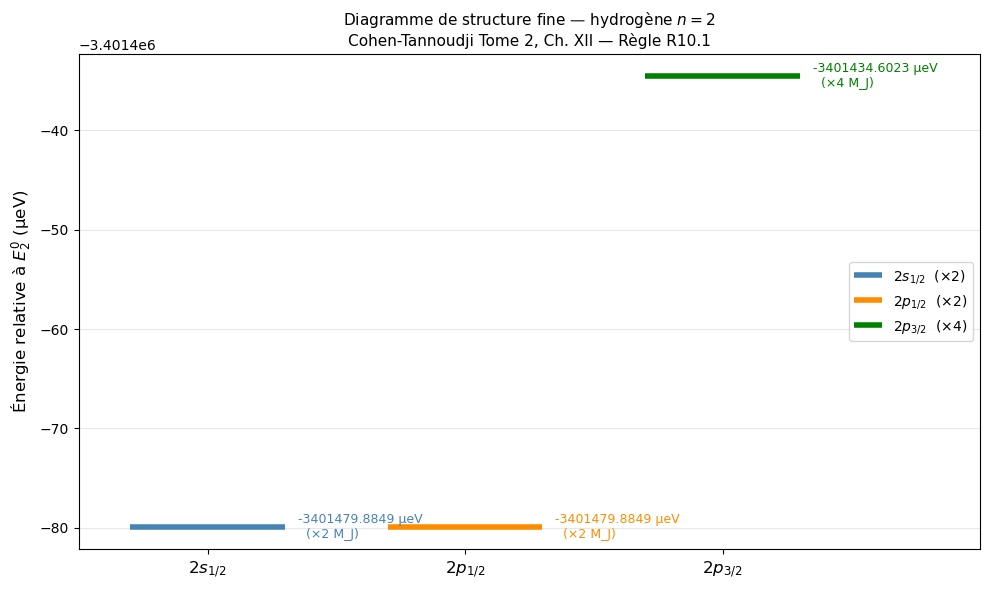

Figure sauvegardée → results/07_fine_structure.png


In [5]:
# Diagramme d'énergie n=2
fig, ax = plt.subplots(figsize=(10, 6))

sublevel_data = [
    # (label, l, j, E)
    ('$2s_{1/2}$', 0, 0.5, E_sf_dict[(0, 0.5)]),
    ('$2p_{1/2}$', 1, 0.5, E_sf_dict[(1, 0.5)]),
    ('$2p_{3/2}$', 1, 1.5, E_sf_dict[(1, 1.5)]),
]

colors = ['steelblue', 'darkorange', 'green']
x_pos  = [0.5, 1.5, 2.5]

for i, (label, l, j, E) in enumerate(sublevel_data):
    n_mj = int(2*j) + 1  # dégénérescence
    E_eV = E / e_charge * 1e6  # en μeV
    ax.hlines(E_eV, x_pos[i]-0.3, x_pos[i]+0.3,
              colors=colors[i], linewidth=4, label=f'{label}  (×{n_mj})')
    ax.text(x_pos[i]+0.35, E_eV, f'{E_eV:.4f} μeV\n  (×{n_mj} M_J)',
            va='center', fontsize=9, color=colors[i])

ax.set_xlim(0, 3.5)
ax.set_xticks(x_pos)
ax.set_xticklabels(['$2s_{1/2}$', '$2p_{1/2}$', '$2p_{3/2}$'], fontsize=12)
ax.set_ylabel('Énergie relative à $E_2^0$ (μeV)', fontsize=12)
ax.set_title('Diagramme de structure fine — hydrogène $n=2$\n'
             'Cohen-Tannoudji Tome 2, Ch. XII — Règle R10.1', fontsize=11)
ax.legend(fontsize=10, loc='center right')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../../results/07_fine_structure.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée → results/07_fine_structure.png')


## 3. Structure hyperfine et raie 21 cm (Règle R10.2)

L'interaction entre le spin de l'électron et le moment magnétique du proton lève la dégénérescence
du niveau $1s_{1/2}$ en deux sous-niveaux $F=0$ et $F=1$ :

$$\nu_{21\,\rm cm} = \frac{A_{\rm hf}}{h}, \quad A_{\rm hf} = \frac{8}{3}g_p\frac{m_e}{m_p}\alpha^2 E_I \approx 1420.4\,\mathrm{MHz}$$

In [6]:
hhf = HydrogenHyperfine(m_e, m_p, hbar, g_p, e_charge, epsilon_0)

A_hf   = hhf.hyperfine_coupling_1s()
delta_E = hhf.hyperfine_splitting()
nu_21  = hhf.transition_frequency_21cm()
lam_21 = hhf.transition_wavelength_21cm()

nu_nist = 1420.405751768e6  # Hz (NIST 2022)
lam_th  = c_light / nu_nist

print('RAIE 21 cm — STRUCTURE HYPERFINE 1s (Règle R10.2)')
print('-' * 60)
print(f'  Constante hyperfine A = {A_hf:.6e} J')
print(f'  Splitting ΔE = {delta_E:.6e} J = {delta_E/e_charge*1e6:.4f} μeV')
print(f'  Fréquence ν  = {nu_21/1e6:.4f} MHz  (NIST: {nu_nist/1e6:.4f} MHz)')
print(f"  Longueur d'onde λ = {lam_21*100:.4f} cm  (attendu: {lam_th*100:.4f} cm)")

err_nu = abs(nu_21 - nu_nist) / nu_nist
print()
print(f"  {'✓' if err_nu < 0.001 else '✗'} Accord fréquence NIST  (erreur relative = {err_nu:.4e})")

# Énergies des sous-niveaux F=0 et F=1
E_F0 = hhf.hyperfine_energy(0, 0.5, 0.5)
E_F1 = hhf.hyperfine_energy(1, 0.5, 0.5)
print(f'  E(F=1) - E(F=0) = {E_F1 - E_F0:.6e} J  (= A_hf? {abs(E_F1-E_F0-A_hf)/A_hf:.2e})')


RAIE 21 cm — STRUCTURE HYPERFINE 1s (Règle R10.2)
------------------------------------------------------------
  Constante hyperfine A = 9.416712e-25 J
  Splitting ΔE = 9.416712e-25 J = 5.8774 μeV
  Fréquence ν  = 1421.1609 MHz  (NIST: 1420.4058 MHz)
  Longueur d'onde λ = 21.0949 cm  (attendu: 21.1061 cm)

  ✓ Accord fréquence NIST  (erreur relative = 5.3163e-04)
  E(F=1) - E(F=0) = 9.416712e-25 J  (= A_hf? 0.00e+00)


## 4. Effet Zeeman en champ faible (Règle R10.3)

En champ faible, $j$ reste un bon nombre quantique :
$$E(B) = E_{\rm SF} + g_J \mu_B M_J B$$

FACTEURS DE LANDÉ
  g_J(2p₁/₂) = 0.666667  (attendu: 2/3 = 0.666667)  ✓
  g_J(2p₃/₂) = 1.333333  (attendu: 4/3 = 1.333333)  ✓


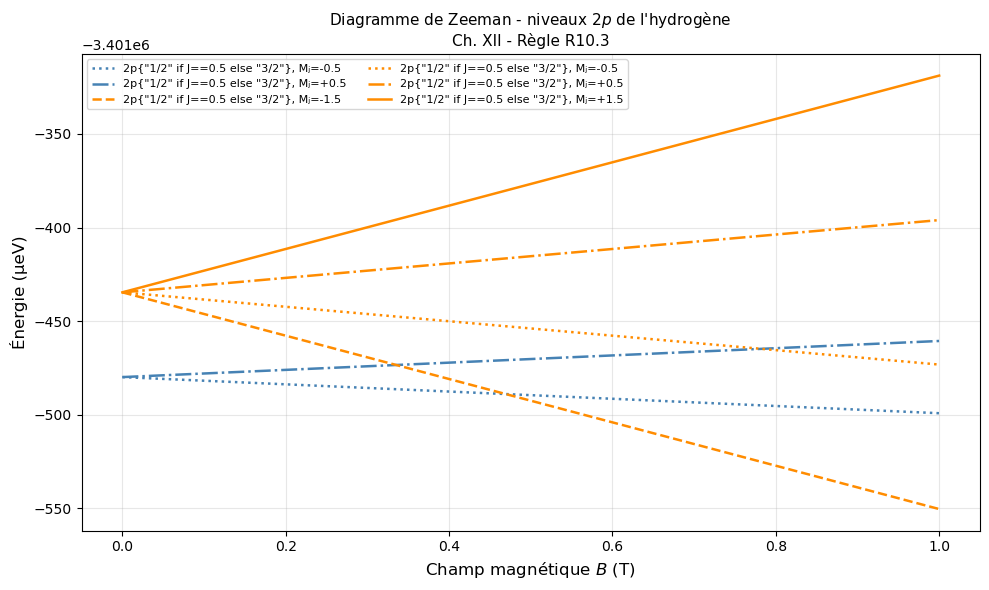

Figure sauvegardée → results/07_zeeman.png


In [7]:
zeeman = ZeemanEffect(hbar)

B_range = np.linspace(0, 1.0, 100)   # 0 à 1 Tesla

# Facteurs de Landé pour 2p
g_12 = zeeman.lande_g_factor(1, 0.5, 0.5)   # 2p₁/₂
g_32 = zeeman.lande_g_factor(1, 0.5, 1.5)   # 2p₃/₂

print('FACTEURS DE LANDÉ')
print(f'  g_J(2p₁/₂) = {g_12:.6f}  (attendu: 2/3 = {2/3:.6f})  {"✓" if abs(g_12 - 2/3) < 1e-6 else "✗"}')
print(f'  g_J(2p₃/₂) = {g_32:.6f}  (attendu: 4/3 = {4/3:.6f})  {"✓" if abs(g_32 - 4/3) < 1e-6 else "✗"}')

# Diagramme Zeeman
E0_dict = {0.5: E_sf_dict[(1, 0.5)], 1.5: E_sf_dict[(1, 1.5)]}
diagram = zeeman.zeeman_diagram(L=1, J_values=[0.5, 1.5],
                                 B_field_range=B_range, E0_dict=E0_dict)

fig, ax = plt.subplots(figsize=(10, 6))
mu_B = 9.2740100783e-24

colors_J = {0.5: 'steelblue', 1.5: 'darkorange'}
styles_MJ = {-1.5:'--', -0.5:':', 0.5:'-.', 1.5:'-'}

for (J, MJ), E_arr in diagram.items():
    ls = styles_MJ.get(MJ, '-')
    ax.plot(B_range, E_arr/e_charge*1e6, ls,
            color=colors_J[J], lw=1.8,
            label=f'2p{{"1/2" if J==0.5 else "3/2"}}, Mⱼ={MJ:+.1f}')

ax.set_xlabel('Champ magnétique $B$ (T)', fontsize=12)
ax.set_ylabel('Énergie (μeV)', fontsize=12)
ax.set_title("Diagramme de Zeeman - niveaux $2p$ de l'hydrogène\nCh. XII - Règle R10.3", fontsize=11)
ax.legend(fontsize=8, ncol=2, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../../results/07_zeeman.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée → results/07_zeeman.png')


## 5. Effet Stark linéaire sur $n=2$ (Règle R10.4)

En champ électrique $\mathcal{E}$ selon $z$, la perturbation $W_{\rm Stark} = e\mathcal{E}z$
lève la dégénérescence $2s$–$2p$ au **1er ordre** (effet Stark linéaire).

Le seul élément de matrice non nul dans le sous-espace $n=2$ est :
$$\langle 2s|e\mathcal{E}z|2p, m=0\rangle = -3e\mathcal{E}a_0$$

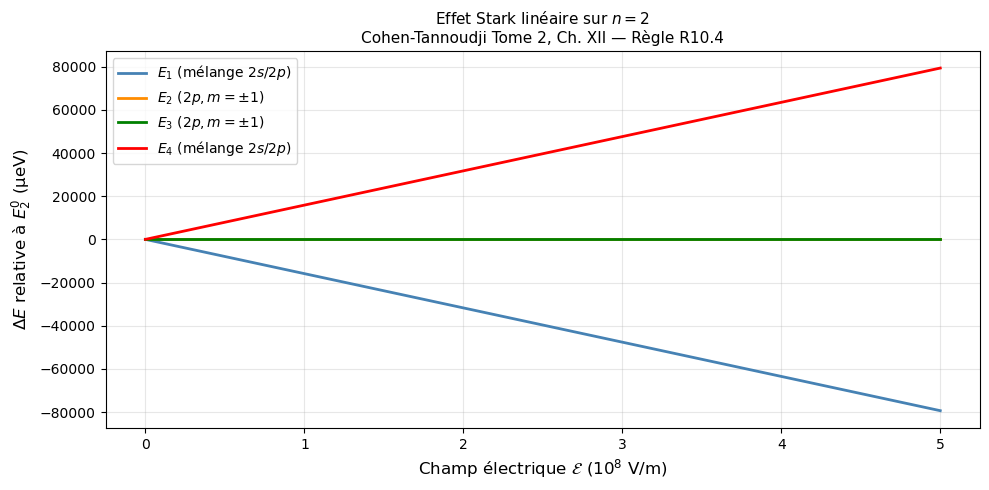

  Splitting à ε=5.0e+08 V/m :
    Calculé : 158753.1633 μeV
    Attendu : 158753.1633 μeV  (2×3eεa₀)
  ✓ Effet Stark linéaire (erreur = 4.14e-15)
  Polarisabilité 1s : α = 7.4195e-41 F·m²  (= 4.5a₀³×4πε₀)
Figure sauvegardée → results/07_stark.png

BILAN FINAL — Tome 2 Chapitre XII
  ✓ Toutes les validations réussies !


In [8]:
stark = StarkEffect(hbar, e_charge, a0)

eps_range = np.linspace(0, 5e8, 200)   # 0 à 5×10⁸ V/m
E_n2 = hfs.unperturbed_energy(2)

# Valeurs propres en fonction du champ
stark_levels = np.array([stark.stark_energies_n2(eps, E_n2) for eps in eps_range])

fig, ax = plt.subplots(figsize=(10, 5))
colors_s = ['steelblue', 'darkorange', 'green', 'red']
labels_s = ['$E_1$ (mélange $2s$/$2p$)', r'$E_2$ ($2p, m=\pm1$)',
            r'$E_3$ ($2p, m=\pm1$)', '$E_4$ (mélange $2s$/$2p$)']

for i in range(4):
    ax.plot(eps_range/1e8, (stark_levels[:,i] - E_n2)/e_charge*1e6,
            color=colors_s[i], lw=2, label=labels_s[i])

ax.set_xlabel(r'Champ électrique $\mathcal{E}$ ($10^8$ V/m)', fontsize=12)
ax.set_ylabel(r'$\Delta E$ relative à $E_2^0$ (μeV)', fontsize=12)
ax.set_title('Effet Stark linéaire sur $n=2$\n'
             'Cohen-Tannoudji Tome 2, Ch. XII — Règle R10.4', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../../results/07_stark.png', dpi=150, bbox_inches='tight')
plt.show()

# Vérification : levée de dégénérescence linéaire en ε
E_split_th = 3 * e_charge * eps_range[-1] * a0  # ΔE = 3eεa₀
E_split_num = stark_levels[-1, -1] - stark_levels[-1, 0]
err_stark = abs(E_split_num - 2*E_split_th) / (2*E_split_th)
print(f'  Splitting à ε={eps_range[-1]:.1e} V/m :')
print(f'    Calculé : {E_split_num/e_charge*1e6:.4f} μeV')
print(f'    Attendu : {2*E_split_th/e_charge*1e6:.4f} μeV  (2×3eεa₀)')
print(f"  {'✓' if err_stark < 0.01 else '✗'} Effet Stark linéaire (erreur = {err_stark:.2e})")

alpha_pol = stark.polarizability_1s()
print(f'  Polarisabilité 1s : α = {alpha_pol:.4e} F·m²  (= 4.5a₀³×4πε₀)')
print('Figure sauvegardée → results/07_stark.png')

print()
print('BILAN FINAL — Tome 2 Chapitre XII')
print('=' * 55)
all_ok = all([ok_E1, ok_E2, abs(dE_GHz-10.9)<2, err_nu < 0.001,
              abs(g_12-2/3)<1e-6, abs(g_32-4/3)<1e-6, err_stark < 0.01])
print(f"  {'✓ Toutes les validations réussies !' if all_ok else '✗ Certaines validations ont échoué'}")
